# Import needed modules

In [1]:
!pip install tensorflow

  Using cached tensorflow-2.18.0-cp312-cp312-win_amd64.whl.metadata (3.3 kB)
Using cached tensorflow-2.18.0-cp312-cp312-win_amd64.whl (7.5 kB)



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install opencv-python


   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   - -------------------------------------- 1.6/39.5 MB 21.1 MB/s eta 0:00:02
   -- ------------------------------------- 2.1/39.5 MB 5.1 MB/s eta 0:00:08
   -- ------------------------------------- 2.1/39.5 MB 5.1 MB/s eta 0:00:08
   -- ------------------------------------- 2.4/39.5 MB 3.4 MB/s eta 0:00:12
   -- ------------------------------------- 2.9/39.5 MB 3.0 MB/s eta 0:00:13
   --- ------------------------------------ 3.4/39.5 MB 2.9 MB/s eta 0:00:13
   --- ------------------------------------ 3.9/39.5 MB 2.9 MB/s eta 0:00:13
   ---- ----------------------------------- 4.7/39.5 MB 3.0 MB/s eta 0:00:12
   ----- ---------------------------------- 5.2/39.5 MB 2.9 MB/s eta 0:00:12
   ------- -------------------------------- 7.6/39.5 MB 3.6 MB/s eta 0:00:09
   ----------- ---------------------------- 11.8/39.5 MB 5.1 MB/s eta 0:00:06
   ----------------- ---------------------- 17.3/39.5 MB 6.9 MB/s eta 0:00:04
   


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# import system libs
import os
import time
import shutil
import pathlib
import itertools

# import data handling tools
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# import Deep learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

 

# Create needed functions

## Functions to Create Data Frame from Dataset

#### **Function to create data frame**

In [7]:
# Generate data paths with labels
def define_paths(data_dir):
    filepaths = []
    labels = []

    folds = os.listdir(data_dir)
    for fold in folds:
        foldpath = os.path.join(data_dir, fold)
        filelist = os.listdir(foldpath)
        for file in filelist:
            fpath = os.path.join(foldpath, file)
            filepaths.append(fpath)
            labels.append(fold)

    return filepaths, labels


# Concatenate data paths with labels into one dataframe ( to later be fitted into the model )
def define_df(files, classes):
    Fseries = pd.Series(files, name= 'filepaths')
    Lseries = pd.Series(classes, name='labels')
    return pd.concat([Fseries, Lseries], axis= 1)

# Split dataframe to train, valid, and test
def split_data(data_dir):
    # train dataframe
    files, classes = define_paths(data_dir)
    df = define_df(files, classes)
    strat = df['labels']
    train_df, dummy_df = train_test_split(df,  train_size= 0.8, shuffle= True, random_state= 123, stratify= strat)

    # valid and test dataframe
    strat = dummy_df['labels']
    valid_df, test_df = train_test_split(dummy_df,  train_size= 0.5, shuffle= True, random_state= 123, stratify= strat)

    return train_df, valid_df, test_df

#### Function to generate images from dataframe

In [8]:
# Import necessary modules
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def create_gens(train_df, valid_df, test_df, batch_size):
    '''
    This function takes train, validation, and test dataframes and fits them into image data generators. 
    Image data generators convert images into tensors and apply data augmentation.
    '''

    # Define model parameters
    img_size = (224, 224)  # Fixed unmatched '}'
    channels = 3  # Either BGR or Grayscale
    color = 'rgb'
    img_shape = (img_size[0], img_size[1], channels)

    # Handle test batch size dynamically
    ts_length = len(test_df)
    if ts_length > 0:
        test_batch_size = max(
            sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length % n == 0 and ts_length / n <= 80])
        )
    else:
        test_batch_size = batch_size  # Fallback to batch_size if test_df is empty

    # Define a simple function for preprocessing (identity function)
    def scalar(img):
        return img

    # ImageDataGenerators
    tr_gen = ImageDataGenerator(preprocessing_function=scalar, horizontal_flip=True)
    ts_gen = ImageDataGenerator(preprocessing_function=scalar)

    # Create data generators
    train_gen = tr_gen.flow_from_dataframe(train_df, x_col='filepaths', y_col='labels', 
                                           target_size=img_size, class_mode='categorical',
                                           color_mode=color, shuffle=True, batch_size=batch_size)

    valid_gen = ts_gen.flow_from_dataframe(valid_df, x_col='filepaths', y_col='labels', 
                                           target_size=img_size, class_mode='categorical',
                                           color_mode=color, shuffle=True, batch_size=batch_size)

    # Ensure test data is not shuffled
    test_gen = ts_gen.flow_from_dataframe(test_df, x_col='filepaths', y_col='labels', 
                                          target_size=img_size, class_mode='categorical',
                                          color_mode=color, shuffle=False, batch_size=test_batch_size)

    return train_gen, valid_gen, test_gen


#### **Function to display data sample**

In [9]:
def show_images(gen):
    '''
    This function take the data generator and show sample of the images
    '''

    # return classes , images to be displayed
    g_dict = gen.class_indices        # defines dictionary {'class': index}
    classes = list(g_dict.keys())     # defines list of dictionary's kays (classes), classes names : string
    images, labels = next(gen)        # get a batch size samples from the generator

    # calculate number of displayed samples
    length = len(labels)        # length of batch size
    sample = min(length, 25)    # check if sample less than 25 images

    plt.figure(figsize= (20, 20))

    for i in range(sample):
        plt.subplot(5, 5, i + 1)
        image = images[i] / 255       # scales data to range (0 - 255)
        plt.imshow(image)
        index = np.argmax(labels[i])  # get image index
        class_name = classes[index]   # get class of image
        plt.title(class_name, color= 'blue', fontsize= 12)
        plt.axis('off')
    plt.show()

#### **Callbacks** 
<br> 
Callbacks : Helpful functions to help optimize model training  <br> 
Examples: stop model training after specfic time, stop training if no improve in accuracy and so on.

In [10]:
class MyCallback(keras.callbacks.Callback):
    def __init__(self, model, patience, stop_patience, threshold, factor, batches, epochs, ask_epoch):
        super(MyCallback, self).__init__()
        self.model = model
        self.patience = patience # specifies how many epochs without improvement before learning rate is adjusted
        self.stop_patience = stop_patience # specifies how many times to adjust lr without improvement to stop training
        self.threshold = threshold # specifies training accuracy threshold when lr will be adjusted based on validation loss
        self.factor = factor # factor by which to reduce the learning rate
        self.batches = batches # number of training batch to run per epoch
        self.epochs = epochs
        self.ask_epoch = ask_epoch
        self.ask_epoch_initial = ask_epoch # save this value to restore if restarting training

        # callback variables
        self.count = 0 # how many times lr has been reduced without improvement
        self.stop_count = 0
        self.best_epoch = 1   # epoch with the lowest loss
        self.initial_lr = float(tf.keras.backend.get_value(model.optimizer.lr)) # get the initial learning rate and save it
        self.highest_tracc = 0.0 # set highest training accuracy to 0 initially
        self.lowest_vloss = np.inf # set lowest validation loss to infinity initially
        self.best_weights = self.model.get_weights() # set best weights to model's initial weights
        self.initial_weights = self.model.get_weights()   # save initial weights if they have to get restored

    # Define a function that will run when train begins
    def on_train_begin(self, logs= None):
        msg = 'Do you want model asks you to halt the training [y/n] ?'
        print(msg)
        ans = input('')
        if ans in ['Y', 'y']:
            self.ask_permission = 1
        elif ans in ['N', 'n']:
            self.ask_permission = 0

        msg = '{0:^8s}{1:^10s}{2:^9s}{3:^9s}{4:^9s}{5:^9s}{6:^9s}{7:^10s}{8:10s}{9:^8s}'.format('Epoch', 'Loss', 'Accuracy', 'V_loss', 'V_acc', 'LR', 'Next LR', 'Monitor','% Improv', 'Duration')
        print(msg)
        self.start_time = time.time()


    def on_train_end(self, logs= None):
        stop_time = time.time()
        tr_duration = stop_time - self.start_time
        hours = tr_duration // 3600
        minutes = (tr_duration - (hours * 3600)) // 60
        seconds = tr_duration - ((hours * 3600) + (minutes * 60))

        msg = f'training elapsed time was {str(hours)} hours, {minutes:4.1f} minutes, {seconds:4.2f} seconds)'
        print(msg)

        # set the weights of the model to the best weights
        self.model.set_weights(self.best_weights)


    def on_train_batch_end(self, batch, logs= None):
        # get batch accuracy and loss
        acc = logs.get('accuracy') * 100
        loss = logs.get('loss')

        # prints over on the same line to show running batch count
        msg = '{0:20s}processing batch {1:} of {2:5s}-   accuracy=  {3:5.3f}   -   loss: {4:8.5f}'.format(' ', str(batch), str(self.batches), acc, loss)
        print(msg, '\r', end= '')


    def on_epoch_begin(self, epoch, logs= None):
        self.ep_start = time.time()


    # Define method runs on the end of each epoch
    def on_epoch_end(self, epoch, logs= None):
        ep_end = time.time()
        duration = ep_end - self.ep_start

        lr = float(tf.keras.backend.get_value(self.model.optimizer.lr)) # get the current learning rate
        current_lr = lr
        acc = logs.get('accuracy')  # get training accuracy
        v_acc = logs.get('val_accuracy')  # get validation accuracy
        loss = logs.get('loss')  # get training loss for this epoch
        v_loss = logs.get('val_loss')  # get the validation loss for this epoch

        if acc < self.threshold: # if training accuracy is below threshold adjust lr based on training accuracy
            monitor = 'accuracy'
            if epoch == 0:
                pimprov = 0.0
            else:
                pimprov = (acc - self.highest_tracc ) * 100 / self.highest_tracc # define improvement of model progres

            if acc > self.highest_tracc: # training accuracy improved in the epoch
                self.highest_tracc = acc # set new highest training accuracy
                self.best_weights = self.model.get_weights() # training accuracy improved so save the weights
                self.count = 0 # set count to 0 since training accuracy improved
                self.stop_count = 0 # set stop counter to 0
                if v_loss < self.lowest_vloss:
                    self.lowest_vloss = v_loss
                self.best_epoch = epoch + 1  # set the value of best epoch for this epoch

            else:
                # training accuracy did not improve check if this has happened for patience number of epochs
                # if so adjust learning rate
                if self.count >= self.patience - 1: # lr should be adjusted
                    lr = lr * self.factor # adjust the learning by factor
                    tf.keras.backend.set_value(self.model.optimizer.lr, lr) # set the learning rate in the optimizer
                    self.count = 0 # reset the count to 0
                    self.stop_count = self.stop_count + 1 # count the number of consecutive lr adjustments
                    self.count = 0 # reset counter
                    if v_loss < self.lowest_vloss:
                        self.lowest_vloss = v_loss
                else:
                    self.count = self.count + 1 # increment patience counter

        else: # training accuracy is above threshold so adjust learning rate based on validation loss
            monitor = 'val_loss'
            if epoch == 0:
                pimprov = 0.0

            else:
                pimprov = (self.lowest_vloss - v_loss ) * 100 / self.lowest_vloss

            if v_loss < self.lowest_vloss: # check if the validation loss improved
                self.lowest_vloss = v_loss # replace lowest validation loss with new validation loss
                self.best_weights = self.model.get_weights() # validation loss improved so save the weights
                self.count = 0 # reset count since validation loss improved
                self.stop_count = 0
                self.best_epoch = epoch + 1 # set the value of the best epoch to this epoch

            else: # validation loss did not improve
                if self.count >= self.patience - 1: # need to adjust lr
                    lr = lr * self.factor # adjust the learning rate
                    self.stop_count = self.stop_count + 1 # increment stop counter because lr was adjusted
                    self.count = 0 # reset counter
                    tf.keras.backend.set_value(self.model.optimizer.lr, lr) # set the learning rate in the optimizer

                else:
                    self.count = self.count + 1 # increment the patience counter

                if acc > self.highest_tracc:
                    self.highest_tracc = acc

        msg = f'{str(epoch + 1):^3s}/{str(self.epochs):4s} {loss:^9.3f}{acc * 100:^9.3f}{v_loss:^9.5f}{v_acc * 100:^9.3f}{current_lr:^9.5f}{lr:^9.5f}{monitor:^11s}{pimprov:^10.2f}{duration:^8.2f}'
        print(msg)

        if self.stop_count > self.stop_patience - 1: # check if learning rate has been adjusted stop_count times with no improvement
            msg = f' training has been halted at epoch {epoch + 1} after {self.stop_patience} adjustments of learning rate with no improvement'
            print(msg)
            self.model.stop_training = True # stop training

        else:
            if self.ask_epoch != None and self.ask_permission != 0:
                if epoch + 1 >= self.ask_epoch:
                    msg = 'enter H to halt training or an integer for number of epochs to run then ask again'
                    print(msg)

                    ans = input('')
                    if ans == 'H' or ans == 'h':
                        msg = f'training has been halted at epoch {epoch + 1} due to user input'
                        print(msg)
                        self.model.stop_training = True # stop training

                    else:
                        try:
                            ans = int(ans)
                            self.ask_epoch += ans
                            msg = f' training will continue until epoch {str(self.ask_epoch)}'
                            print(msg)
                            msg = '{0:^8s}{1:^10s}{2:^9s}{3:^9s}{4:^9s}{5:^9s}{6:^9s}{7:^10s}{8:10s}{9:^8s}'.format('Epoch', 'Loss', 'Accuracy', 'V_loss', 'V_acc', 'LR', 'Next LR', 'Monitor', '% Improv', 'Duration')
                            print(msg)

                        except Exception:
                            print('Invalid')

#### **Function to plot history of training**

In [11]:
def plot_training(hist):
    '''
    This function take training model and plot history of accuracy and losses with the best epoch in both of them.
    '''

    # Define needed variables
    tr_acc = hist.history['accuracy']
    tr_loss = hist.history['loss']
    val_acc = hist.history['val_accuracy']
    val_loss = hist.history['val_loss']
    
    index_loss = np.argmin(val_loss)
    val_lowest = val_loss[index_loss]
    index_acc = np.argmax(val_acc)
    acc_highest = val_acc[index_acc]
    
    Epochs = [i+1 for i in range(len(tr_acc))]
    
    loss_label = f'best epoch= {str(index_loss + 1)}'
    acc_label = f'best epoch= {str(index_acc + 1)}'

    # Plot training history
    plt.figure(figsize= (20, 8))
    plt.style.use('fivethirtyeight')

    plt.subplot(1, 2, 1)
    plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
    plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
    plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
    plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
    plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout
    plt.show()


# **Model Structure**

#### **Start Reading Dataset**

In [12]:
data_dir = 'color'
try:
    # Get splitted data
    train_df, valid_df, test_df = split_data(data_dir)

    # Get Generators
    batch_size = 40
    train_gen, valid_gen, test_gen = create_gens(train_df, valid_df, test_df, batch_size)

except:
    print('Invalid Input')

Found 2536 validated image filenames belonging to 4 classes.
Found 317 validated image filenames belonging to 4 classes.
Found 318 validated image filenames belonging to 4 classes.


#### **Display Image Sample**

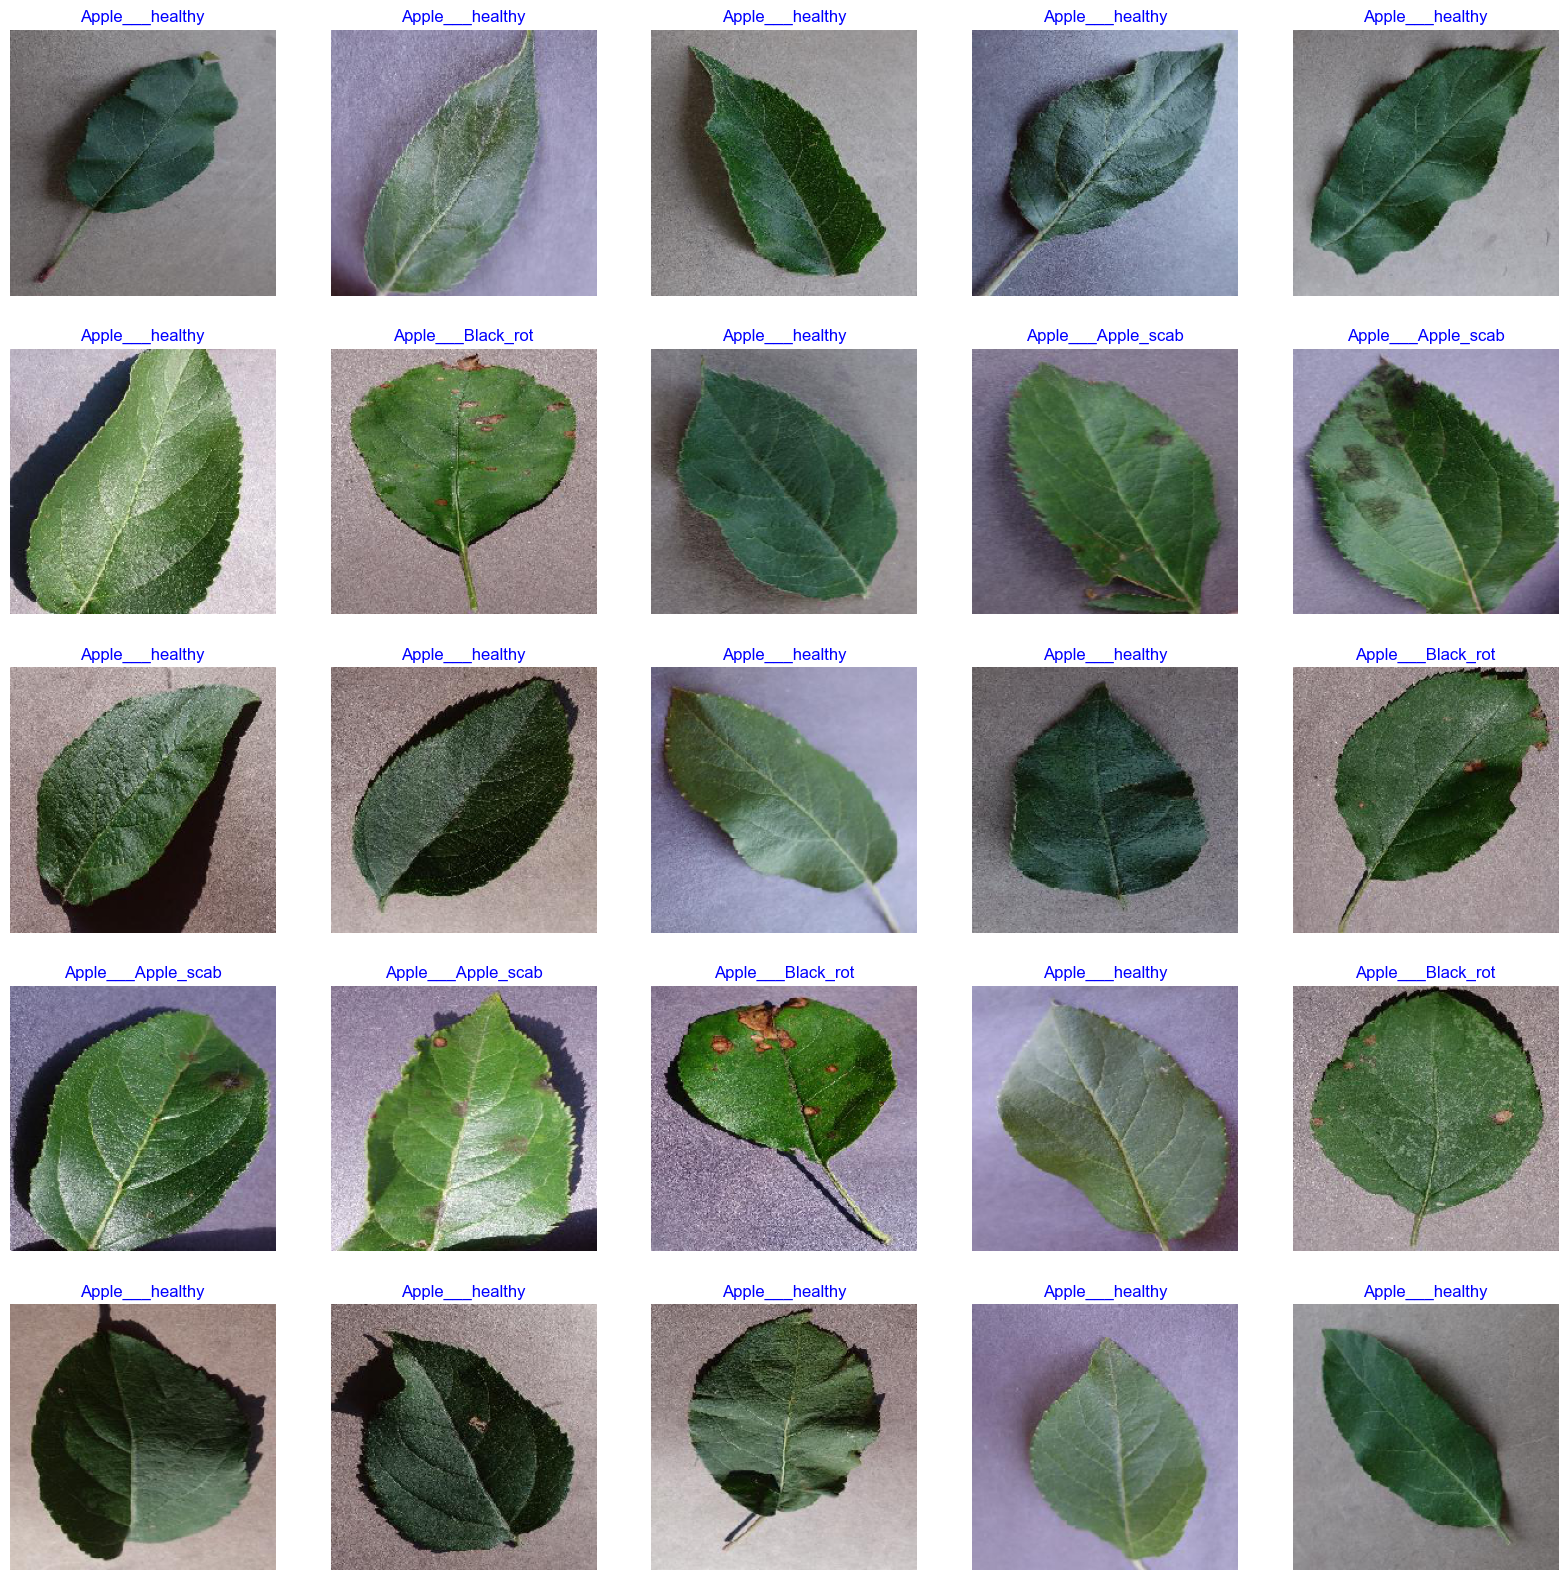

In [13]:
show_images(train_gen)

#### **Generic Model Creation**

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras import regularizers

# Set random seed for reproducibility
tf.random.set_seed(123)

# Define model parameters
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
class_count = len(list(train_gen.class_indices.keys()))  # Number of classes

# Load pre-trained EfficientNetB3 model
base_model = tf.keras.applications.EfficientNetB3(
    include_top=False, weights="imagenet", input_shape=img_shape, pooling="max"
)

# Define the model
model = Sequential([
    base_model,
    BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001),
    Dense(256, kernel_regularizer=regularizers.l2(0.016), 
          activity_regularizer=regularizers.l1(0.006),
          bias_regularizer=regularizers.l1(0.006), activation="relu"),
    Dropout(rate=0.45),  # Removed 'seed' (not needed)
    Dense(class_count, activation="softmax")
])

# Compile the model
model.compile(optimizer=Adamax(learning_rate=0.001), 
              loss="categorical_crossentropy", 
              metrics=["accuracy"])

# Display the model summary
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 1536)           │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,184,179 (42.66 MB)

 Trainable params: 11,093,804 (42.32 MB)

 Non-trainable params: 90,375 (353.03 KB)

#### **Set Callback Parameters**

In [10]:
import tensorflow as tf

class MyCallback(tf.keras.callbacks.Callback):
    def __init__(self, model_instance, patience, stop_patience, threshold, factor, batches, epochs, ask_epoch):
        super(MyCallback, self).__init__()
        self.model_instance = model_instance  # Rename to avoid conflict
        self.patience = patience  # Epochs without improvement before adjusting LR
        self.stop_patience = stop_patience  # Number of adjustments before stopping
        self.threshold = threshold  # Accuracy threshold to switch monitoring metric
        self.factor = factor  # Learning rate reduction factor
        self.batches = batches  # Number of training batches
        self.epochs = epochs  # Total epochs
        self.ask_epoch = ask_epoch  # When to ask for stopping

    def on_epoch_end(self, epoch, logs=None):
        print(f"Epoch {epoch + 1} completed.")

#### **Train model**

In [11]:
import torch
print(torch.cuda.is_available())  # Should return True
print(torch.cuda.device_count())  # Should return the number of GPUs
print(torch.cuda.get_device_name(0))  # Should print the name of your GPU


True
1
NVIDIA GeForce RTX 4060 Laptop GPU


In [12]:
import tensorflow as tf

# Print the device being used
tf.debugging.set_log_device_placement(True)

# Define hyperparameters
patience = 5  
stop_patience = 10  
threshold = 0.01  
factor = 0.5  
batches = 100  
epochs = 50  
ask_epoch = 10  

# Define callbacks
callbacks = [
    MyCallback(
        model_instance=model,  
        patience=patience,
        stop_patience=stop_patience,
        threshold=threshold,
        factor=factor,
        batches=batches,
        epochs=epochs,
        ask_epoch=ask_epoch
    )
]

# Train the model using GPU
with tf.device('/GPU:0'):  # Force GPU usage
    history = model.fit(
        x=train_gen,
        epochs=epochs, 
        verbose=1,  
        callbacks=callbacks,  
        validation_data=valid_gen, 
        shuffle=False
    )

Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.6180 - loss: 25.0648Epoch 1 completed.
64/64 ━━━━━━━━━━━━━━━━━━━━ 754s 10s/step - accuracy: 0.6180 - loss: 24.9196 - val_accuracy: 0.5994 - val_loss: 8.2903
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.5534 - loss: 7.6090Epoch 2 completed.
64/64 ━━━━━━━━━━━━━━━━━━━━ 644s 10s/step - accuracy: 0.5534 - loss: 7.6070 - val_accuracy: 0.5584 - val_loss: 7.4545
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5300 - loss: 7.1481Epoch 3 completed.
64/64 ━━━━━━━━━━━━━━━━━━━━ 206s 3s/step - accuracy: 0.5300 - loss: 7.1469 - val_accuracy: 0.5237 - val_loss: 6.9517
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5245 - loss: 6.7930Epoch 4 completed.
64/64 ━━━━━━━━━━━━━━━━━━━━ 191s 3s/step - accuracy: 0.5245 - loss: 6.7915 - val_accuracy: 0.5268 - val_loss: 6.5079
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5271 - loss: 6.4230Epoch 5 completed.
64/64 ━━━━━━━━━━━━━━━━━━━

Epoch 30/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5281 - loss: 1.7005Epoch 30 completed.
64/64 ━━━━━━━━━━━━━━━━━━━━ 219s 3s/step - accuracy: 0.5279 - loss: 1.7005 - val_accuracy: 0.5205 - val_loss: 1.6625
Epoch 31/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5179 - loss: 1.6551Epoch 31 completed.
64/64 ━━━━━━━━━━━━━━━━━━━━ 225s 4s/step - accuracy: 0.5179 - loss: 1.6548 - val_accuracy: 0.5205 - val_loss: 1.6060
Epoch 32/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5226 - loss: 1.5928Epoch 32 completed.
64/64 ━━━━━━━━━━━━━━━━━━━━ 223s 3s/step - accuracy: 0.5226 - loss: 1.5927 - val_accuracy: 0.5205 - val_loss: 1.5742
Epoch 33/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5243 - loss: 1.5466Epoch 33 completed.
64/64 ━━━━━━━━━━━━━━━━━━━━ 223s 3s/step - accuracy: 0.5243 - loss: 1.5465 - val_accuracy: 0.5205 - val_loss: 1.5127
Epoch 34/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5369 - loss: 1.4802Epoch 34 completed.
64/64 ━━━━━━━━━━━━━━━

#### **Display model performance**

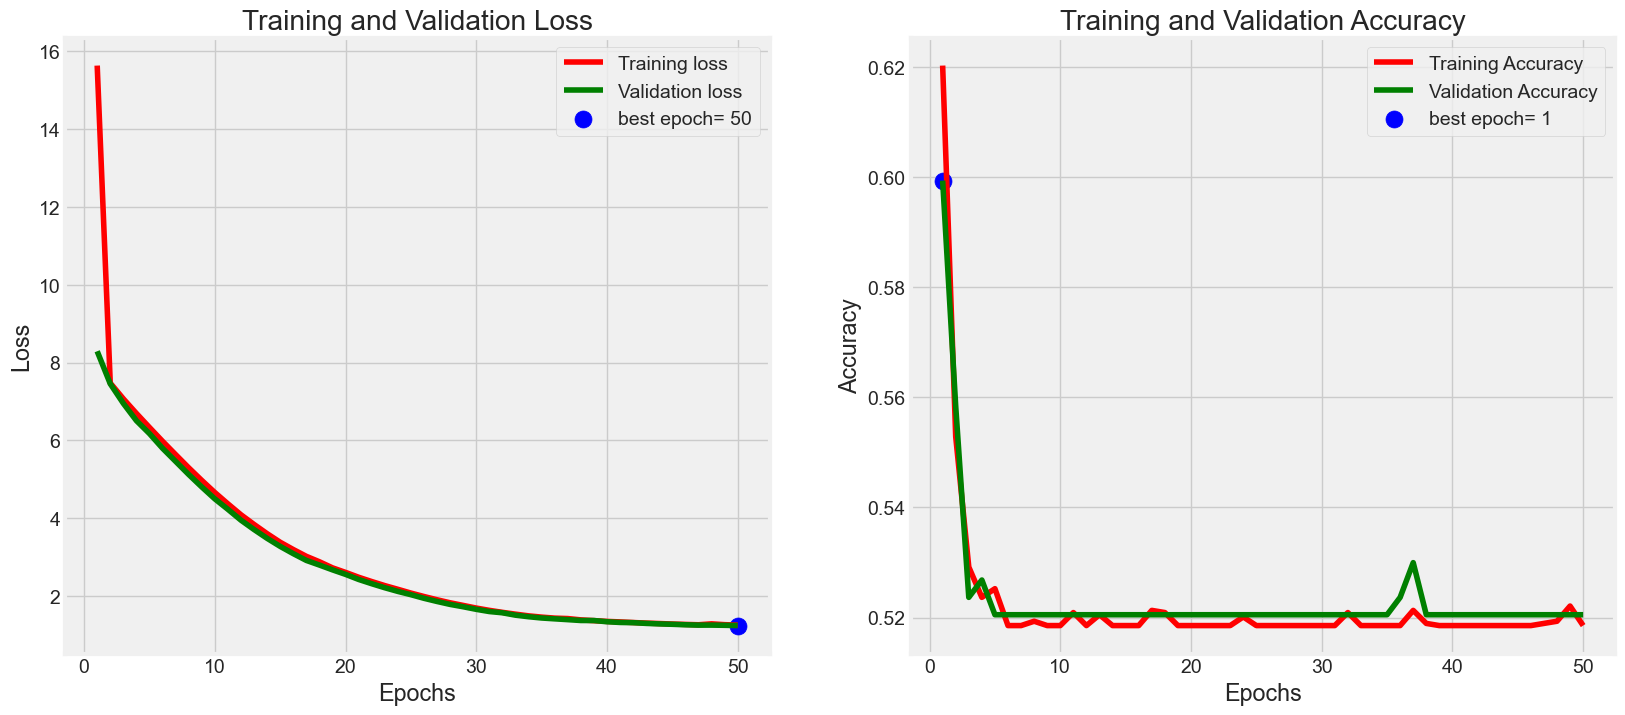

In [13]:
plot_training(history) 

# **Evaluate model**

In [14]:
ts_length = len(test_df)
test_batch_size = test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = model.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 838ms/step - accuracy: 0.4604 - loss: 1.3154
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 909ms/step - accuracy: 0.5442 - loss: 1.2235
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5159 - loss: 1.2484
Train Loss:  1.2784143686294556
Train Accuracy:  0.49166667461395264
--------------------
Validation Loss:  1.2354024648666382
Validation Accuracy:  0.5291666388511658
--------------------
Test Loss:  1.248963713645935
Test Accuracy:  0.5188679099082947


# **Get Predictions**

In [15]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Path to your image
img_path = "00e909aa-e3ae-4558-9961-336bb0f35db3___JR_FrgE.S 8593.JPG"

# Define class labels (Update this list based on your model)
class_labels = ["Apple___Apple_scab", "Apple___Black_rot", "Apple___Cedar_apple_rust", "Apple___healthy"]  

# Load the image and resize it to match your model input size
image_height, image_width = 224, 224  # Update based on your model input
img = image.load_img(img_path, target_size=(image_height, image_width))

# Convert image to array and normalize
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array /= 255.0  # Normalize (same as during training)

# Make prediction
pred = model.predict(img_array)
y_pred = np.argmax(pred, axis=1)  # Get class index

# Get the predicted class label
predicted_class = class_labels[y_pred[0]]

# Print result
print(f"Predicted class: {predicted_class}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted class: Apple___Apple_scab


#### **Confusion Matrics and Classification Report**

In [18]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())
# Classification report
print(classification_report(test_gen.classes, y_pred, target_names= classes))

                          precision    recall  f1-score   support

      Apple___Apple_scab       0.00      0.00      0.00        63
       Apple___Black_rot       0.00      0.00      0.00        62
Apple___Cedar_apple_rust       0.00      0.00      0.00        28
         Apple___healthy       0.52      1.00      0.68       165

                accuracy                           0.52       318
               macro avg       0.13      0.25      0.17       318
            weighted avg       0.27      0.52      0.35       318



#### **Save model**

In [27]:
import os

# Use model.name to avoid index errors
model_name = model.name  # This is safer
subject = 'Plant Village Disease'
acc = test_score[1] * 100
save_path = ''  # Save in the current directory

# Save model
save_id = f'{model_name}-{subject}-{"%.2f" % round(acc, 2)}.h5'
model_save_loc = os.path.join(save_path, save_id)
model.save(model_save_loc)
print(f'Model was saved as {model_save_loc}')

# Save weights
weight_save_id = f'{model_name}-{subject}-weights.h5'
weights_save_loc = os.path.join(save_path, weight_save_id)
model.save_weights(weights_save_loc)
print(f'Weights were saved as {weights_save_loc}')


Model was saved as sequential-Plant Village Disease-51.89.h5


ValueError: The filename must end in `.weights.h5`. Received: filepath=sequential-Plant Village Disease-weights.h5

#### **Generate CSV files containing classes indicies & image size**

In [28]:
class_dict = train_gen.class_indices
img_size = train_gen.image_shape
height = []
width = []
for _ in range(len(class_dict)):
    height.append(img_size[0])
    width.append(img_size[1])
Index_series = pd.Series(list(class_dict.values()), name= 'class_index')
Class_series = pd.Series(list(class_dict.keys()), name= 'class')
Height_series = pd.Series(height, name= 'height')
Width_series = pd.Series(width, name= 'width')
class_df = pd.concat([Index_series, Class_series, Height_series, Width_series], axis= 1)
csv_name = f'{subject}-class_dict.csv'
csv_save_loc = os.path.join(save_path, csv_name)
class_df.to_csv(csv_save_loc, index= False)
print(f'class csv file was saved as {csv_save_loc}')

class csv file was saved as Plant Village Disease-class_dict.csv


In [37]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import cv2
import os

# Define image size and paths
IMG_SIZE = 224  # Standard for pretrained models
DATASET_PATH = "color"  # Path to your dataset

# Load images
def load_images(folder):
    images, labels = [], []
    class_names = os.listdir(folder)  # Get class names

    for class_idx, class_name in enumerate(class_names):
        class_path = os.path.join(folder, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))  # Resize to fixed size
            img = img / 255.0  # Normalize pixels (0-1)
            images.append(img)
            labels.append(class_idx)  # Assign class index

    return np.array(images), np.array(labels), class_names

X, y, class_names = load_images(DATASET_PATH)
print("Loaded dataset with", len(X), "images.")

Loaded dataset with 3171 images.


In [38]:
# Define CNN Model
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(len(class_names), activation="softmax")  # Output layer
])
# Compile Model
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Train Model
model.fit(X, y, epochs=5, validation_split=0.2, batch_size=16)


Epoch 1/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 25s 146ms/step - accuracy: 0.5579 - loss: 1.1086 - val_accuracy: 0.9244 - val_loss: 0.2199
Epoch 2/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 23s 146ms/step - accuracy: 0.8823 - loss: 0.3147 - val_accuracy: 0.9402 - val_loss: 0.1929
Epoch 3/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 24s 148ms/step - accuracy: 0.9159 - loss: 0.2337 - val_accuracy: 0.8441 - val_loss: 0.4543
Epoch 4/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 23s 147ms/step - accuracy: 0.9175 - loss: 0.2200 - val_accuracy: 0.8724 - val_loss: 0.3637
Epoch 5/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 24s 150ms/step - accuracy: 0.9320 - loss: 0.1732 - val_accuracy: 0.8110 - val_loss: 0.4878


## **Thank You..**
If you find this notebook is good enough, please upvote it..

In [39]:
base_model = keras.applications.EfficientNetB0(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False  # Freeze layers

model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(len(class_names), activation="softmax")
])
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.fit(X, y, epochs=10, validation_split=0.2, batch_size=16)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 14s 1us/step
Epoch 1/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 51s 265ms/step - accuracy: 0.3830 - loss: 1.3334 - val_accuracy: 0.0000e+00 - val_loss: 1.2154
Epoch 2/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 50s 315ms/step - accuracy: 0.3954 - loss: 1.2993 - val_accuracy: 1.0000 - val_loss: 1.0584
Epoch 3/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 47s 294ms/step - accuracy: 0.4098 - loss: 1.2982 - val_accuracy: 1.0000 - val_loss: 1.0804
Epoch 4/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 58s 366ms/step - accuracy: 0.4114 - loss: 1.2972 - val_accuracy: 1.0000 - val_loss: 1.0709
Epoch 5/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 56s 353ms/step - accuracy: 0.4114 - loss: 1.2971 - val_accuracy: 1.0000 - val_loss: 1.0827
Epoch 6/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 62s 388ms/step - accuracy: 0.4114 - loss: 1.2974 - val_accuracy: 1.0000 - val_loss: 1.0811
Epoch 7/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 55s 343ms/step - accuracy: 0.4114 - loss: 1.2957 - val_accuracy: 1.0000 - val_loss: 1.0638
Epoch 8/10
159/159 ━━━━━━━━

In [1]:
import cv2
import matplotlib.pyplot as plt

# Load an RGB image
img = cv2.imread("th.jpeg")  # Replace with your image path
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert OpenCV BGR to RGB

# Split into channels
R, G, B = img[:, :, 0], img[:, :, 1], img[:, :, 2]

# Create empty images for each channel
zeros = np.zeros_like(R)

# Merge channels into RGB-like images
red_img = np.stack([R, zeros, zeros], axis=-1)
green_img = np.stack([zeros, G, zeros], axis=-1)
blue_img = np.stack([zeros, zeros, B], axis=-1)

# Plot images
fig, ax = plt.subplots(1, 4, figsize=(15, 5))
ax[0].imshow(img)
ax[0].set_title("Original RGB Image")

ax[1].imshow(red_img)
ax[1].set_title("Red Channel")

ax[2].imshow(green_img)
ax[2].set_title("Green Channel")

ax[3].imshow(blue_img)
ax[3].set_title("Blue Channel")

for a in ax:
    a.axis("off")

plt.show()



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Arvapalli Manikanta\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\Arvapalli Manikanta\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "C:\Users\Arvapalli Manikanta\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 711, in start
    self.io_loop.start()
  Fil

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

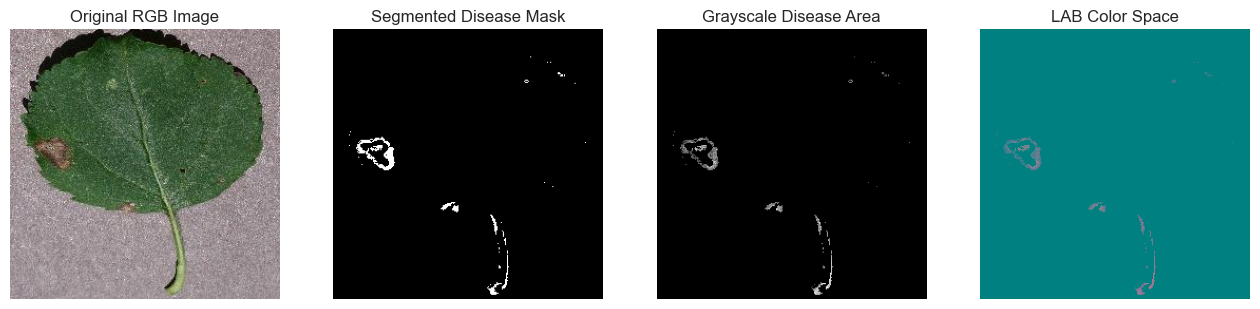

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread("00e909aa-e3ae-4558-9961-336bb0f35db3___JR_FrgE.S 8593.JPG")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB

# Convert to HSV (Hue, Saturation, Value)
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

# Define lower and upper bounds for "diseased" color (adjust these values)
lower_bound = np.array([15, 50, 50])  # Example values for brown/yellow spots
upper_bound = np.array([35, 255, 255])

# Create a mask
mask = cv2.inRange(hsv, lower_bound, upper_bound)

# Extract diseased area
diseased_area = cv2.bitwise_and(img, img, mask=mask)

# Convert the masked region into different color spaces
gray_disease = cv2.cvtColor(diseased_area, cv2.COLOR_RGB2GRAY)  # Grayscale
lab_disease = cv2.cvtColor(diseased_area, cv2.COLOR_RGB2LAB)    # LAB color space

# Plot results
fig, ax = plt.subplots(1, 4, figsize=(16, 6))
ax[0].imshow(img)
ax[0].set_title("Original RGB Image")

ax[1].imshow(mask, cmap="gray")
ax[1].set_title("Segmented Disease Mask")

ax[2].imshow(gray_disease, cmap="gray")
ax[2].set_title("Grayscale Disease Area")

ax[3].imshow(lab_disease)
ax[3].set_title("LAB Color Space")

for a in ax:
    a.axis("off")
plt.show()